
# **Hotel Chain A - Cancellation Prediction Project**

**IMPORT LIBRARIES &  LOAD DATA**

In [ ]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Randima_alex/Hotel-A-train.csv")

In [ ]:
# preview
df.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,7/1/2015,7/2/2015,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,7/2/2015,7/6/2015,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,7/2/2015,7/3/2015,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,7/3/2015,7/4/2015,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


In [ ]:
# shape
df.shape

(27499, 24)

In [ ]:
# descriptive statistics
df.describe()

,Reservation-id,Age,Adults,Children,Babies,Discount_Rate,Room_Rate
count,2.749900e+04,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000,27499.000000
mean,5.016461e+07,43.977454,2.333576,1.743882,0.351540,12.495182,175.136478
std,2.886911e+07,15.303148,1.176526,0.721972,0.573326,11.206036,43.877087
min,3.154000e+03,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000
25%,2.523943e+07,31.000000,2.000000,1.000000,0.000000,5.000000,137.000000
50%,5.014996e+07,44.000000,2.000000,2.000000,0.000000,10.000000,175.000000
75%,7.518288e+07,57.000000,3.000000,2.000000,1.000000,20.000000,214.000000
max,9.999900e+07,70.000000,5.000000,3.000000,2.000000,40.000000,250.000000


In [ ]:
# check data types
df.dtypes

,0
Reservation-id,int64
Gender,object
Age,int64
Ethnicity,object
Educational_Level,object
Income,object
Country_region,object
Hotel_Type,object
Expected_checkin,datetime64[ns]
Expected_checkout,datetime64[ns]


**DATA CLEANING**

In [ ]:
# convert date columns
df['Expected_checkin'] = pd.to_datetime(df['Expected_checkin'])
df['Expected_checkout'] = pd.to_datetime(df['Expected_checkout'])
df['Booking_date'] = pd.to_datetime(df['Booking_date'])
df.head()

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Meal_Type,Visted_Previously,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,2015-07-01,2015-07-02,...,BB,No,No,No Deposit,Online,Yes,Check-Out,Yes,10,218
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,2015-07-01,2015-07-02,...,BB,No,No,Refundable,Online,Yes,Check-Out,No,0,185
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,2015-07-02,2015-07-06,...,BB,No,No,No Deposit,Online,Yes,Check-Out,No,0,119
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,2015-07-02,2015-07-03,...,BB,No,No,Refundable,Agent,Yes,Check-Out,Yes,5,144
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,2015-07-03,2015-07-04,...,BB,No,No,No Deposit,Direct,No,Check-Out,Yes,10,242


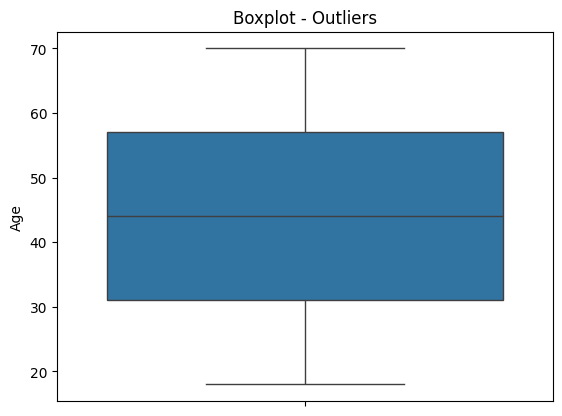

In [ ]:
#checking for outliers using boxplots
sns.boxplot(y=df['Age'])
plt.title('Boxplot - Outliers')
plt.show()

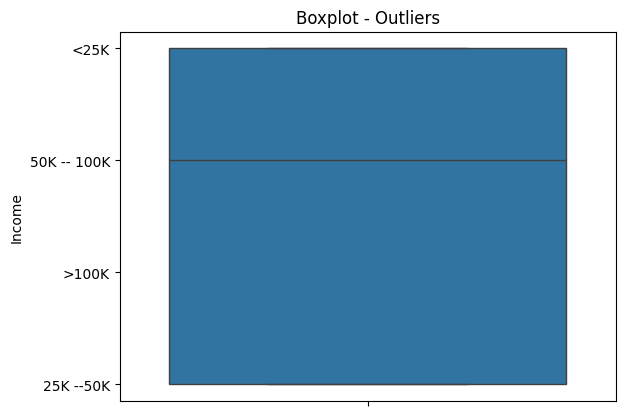

In [ ]:
sns.boxplot(y=df['Income'])
plt.title('Boxplot - Outliers')
plt.show()

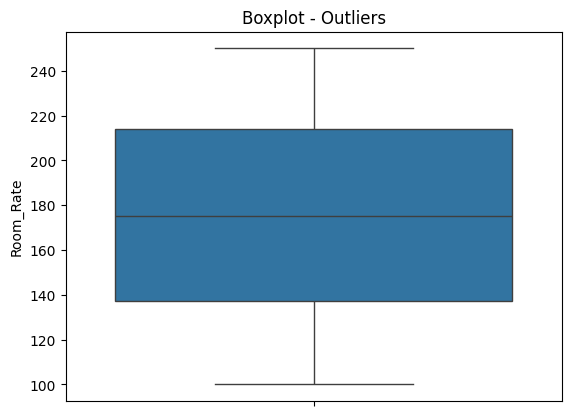

In [ ]:
sns.boxplot(y=df['Room_Rate'])
plt.title('Boxplot - Outliers')
plt.show()

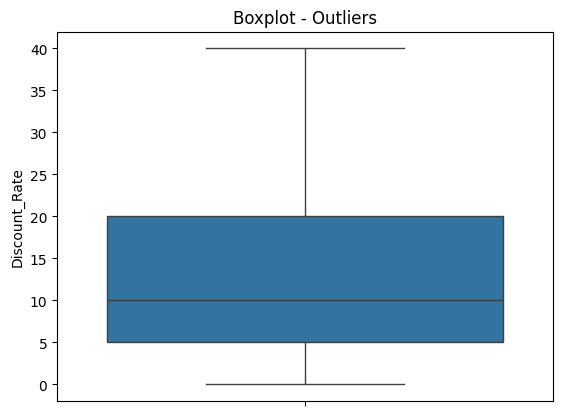

In [ ]:
sns.boxplot(y=df['Discount_Rate'])
plt.title('Boxplot - Outliers')
plt.show()

<Axes: >

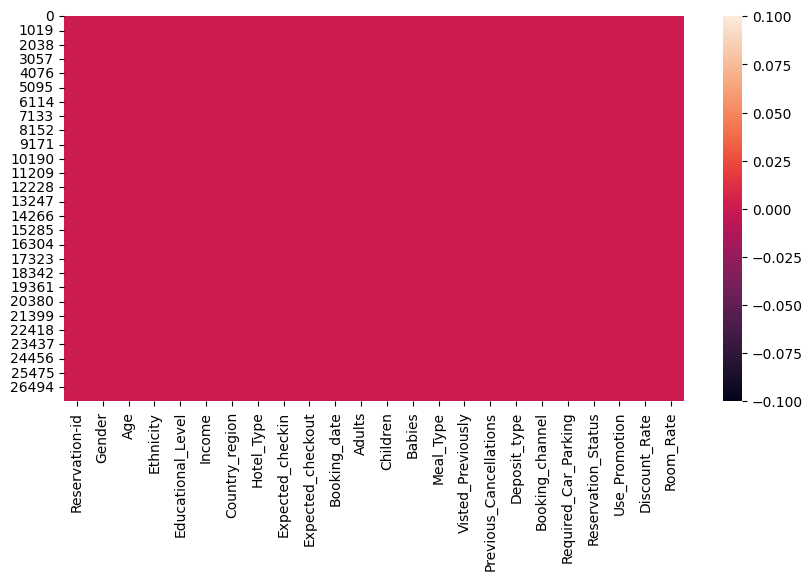

In [ ]:
#checking for missing values
cols = df.columns

plt.figure(figsize = (10,5))

sns.heatmap(df[cols].isnull())

In [ ]:
#number of missing values
df.isnull().sum()

,0
Reservation-id,0
Gender,0
Age,0
Ethnicity,0
Educational_Level,0
Income,0
Country_region,0
Hotel_Type,0
Expected_checkin,0
Expected_checkout,0


In [ ]:
#class imbalance
#lowercasing the reservation status values because of data quality issues
df['Reservation_Status'] = df['Reservation_Status'].str.lower()

**FEATURE ENGINEERING**

In [34]:
#feature engineering
df['Stay_Length'] = (df['Expected_checkout'] - df['Expected_checkin']).dt.days

# Remove invalid stays
df = df[df['Stay_Length'] > 0].copy()

In [ ]:
#creating lead time column
df['Lead_Time'] = (df['Expected_checkin'] - df['Booking_date']).dt.days
df

,Reservation-id,Gender,Age,Ethnicity,Educational_Level,Income,Country_region,Hotel_Type,Expected_checkin,Expected_checkout,...,Previous_Cancellations,Deposit_type,Booking_channel,Required_Car_Parking,Reservation_Status,Use_Promotion,Discount_Rate,Room_Rate,Stay_Length,Lead_Time
0,39428300,F,40,Latino,Grad,<25K,North,City Hotel,2015-07-01,2015-07-02,...,No,No Deposit,Online,Yes,check-out,Yes,10,218,1,41
1,77491756,F,49,Latino,Mid-School,50K -- 100K,East,City Hotel,2015-07-01,2015-07-02,...,No,Refundable,Online,Yes,check-out,No,0,185,1,36
2,73747291,F,42,caucasian,Grad,<25K,East,City Hotel,2015-07-02,2015-07-06,...,No,No Deposit,Online,Yes,check-out,No,0,119,4,3
3,67301739,M,25,African American,College,>100K,South,Airport Hotels,2015-07-02,2015-07-03,...,No,Refundable,Agent,Yes,check-out,Yes,5,144,1,12
4,77222321,F,62,Latino,High-School,25K --50K,East,Resort,2015-07-03,2015-07-04,...,No,No Deposit,Direct,No,check-out,Yes,10,242,1,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27494,15645505,F,49,African American,Mid-School,<25K,West,City Hotel,2016-08-31,2016-09-01,...,Yes,No Deposit,Online,Yes,check-out,Yes,10,100,1,37
27495,56414525,F,49,Asian American,College,25K --50K,South,Airport Hotels,2016-08-31,2016-09-01,...,No,Refundable,Agent,Yes,no-show,Yes,40,194,1,127
27496,52023375,F,49,Latino,High-School,50K -- 100K,South,Airport Hotels,2016-09-01,2016-09-02,...,No,No Deposit,Direct,Yes,check-out,Yes,5,202,1,9
27497,98041387,M,65,African American,College,25K --50K,South,Airport Hotels,2016-08-31,2016-09-01,...,No,No Deposit,Online,No,canceled,Yes,20,157,1,98


In [35]:
#looking for minus values in lead time column
df = df[df['Lead_Time'] >= 0].copy()

In [36]:
#confirming that they are filtered
(df['Lead_Time'] < 0).sum()

np.int64(0)

In [38]:
# adjusted room rate
df['Adjusted_Room_Rate'] = df['Room_Rate'] * (1 - df['Discount_Rate'] / 100)
df['Adjusted_Room_Rate']

,Adjusted_Room_Rate
0,196.2
1,185.0
2,119.0
3,136.8
4,217.8
...,...
27494,90.0
27495,116.4
27496,191.9
27497,125.6


In [39]:
# expected revenue
df['Expected_Revenue'] = df['Adjusted_Room_Rate'] * df['Stay_Length']
df['Expected_Revenue']

,Expected_Revenue
0,196.2
1,185.0
2,476.0
3,136.8
4,217.8
...,...
27494,90.0
27495,116.4
27496,191.9
27497,125.6


**EDA (VISUALS)**

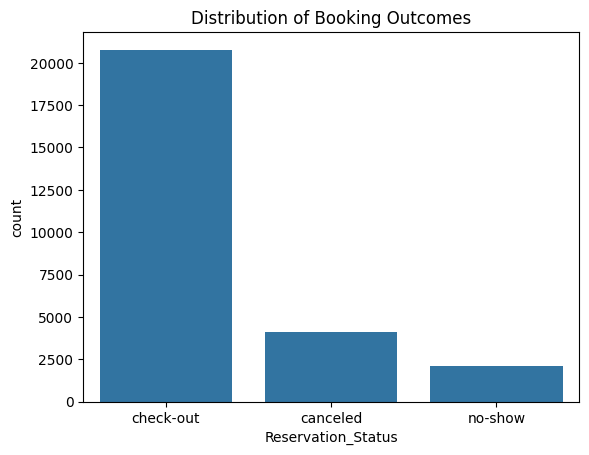

In [40]:
# reservation status distribution
sns.countplot(x='Reservation_Status', data=df)
plt.title("Distribution of Booking Outcomes")
plt.show()

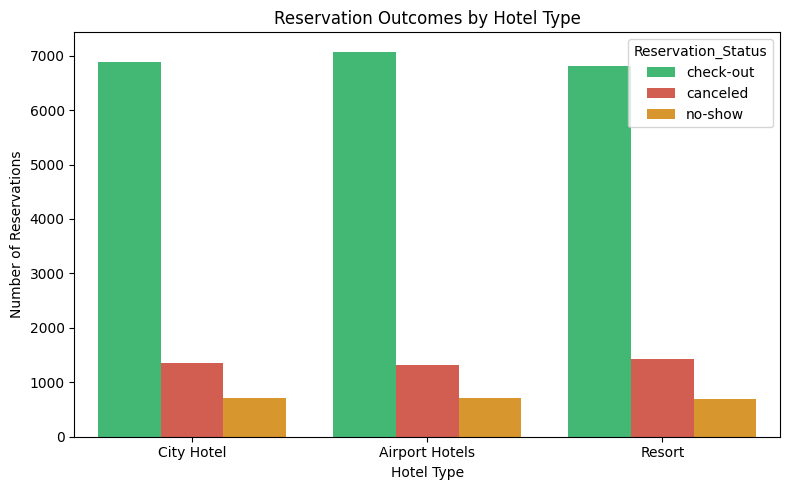

In [42]:
# Reservation Outcomes by Hotel Type

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Hotel_Type',
    hue='Reservation_Status',
    hue_order=['check-out', 'canceled', 'no-show'],
    palette=['#2ECC71', '#E74C3C', '#F39C12'],
    ax=ax
)

ax.set_title("Reservation Outcomes by Hotel Type")
ax.set_xlabel("Hotel Type")
ax.set_ylabel("Number of Reservations")

plt.tight_layout()
plt.show()

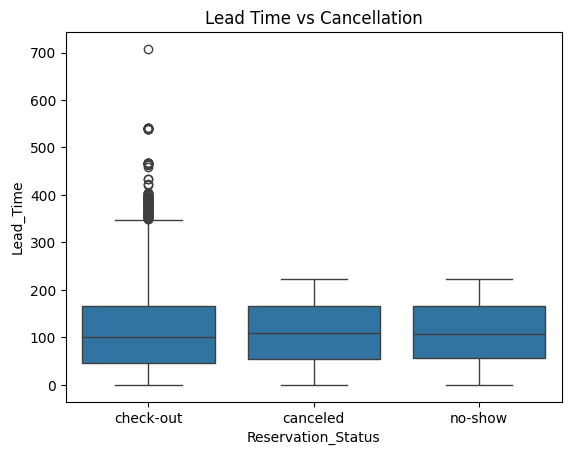

In [44]:
# lead time vs cancellation
sns.boxplot(x='Reservation_Status', y='Lead_Time', data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

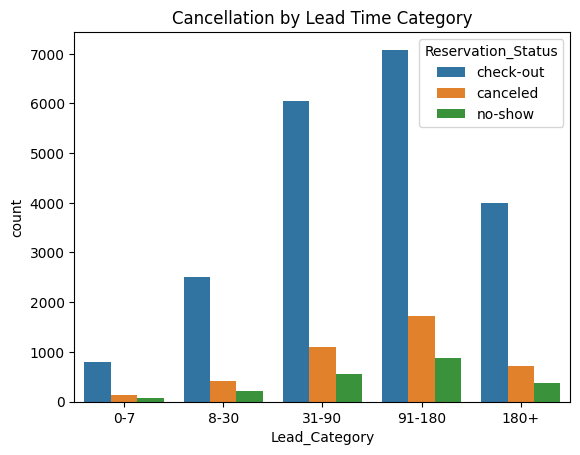

In [48]:
# lead time categories
bins = [0,7,30,90,180,365]
labels = ['0-7','8-30','31-90','91-180','180+']

df['Lead_Category'] = pd.cut(df['Lead_Time'], bins=bins, labels=labels)

sns.countplot(x='Lead_Category', hue='Reservation_Status', data=df)
plt.title("Cancellation by Lead Time Category")
plt.show()

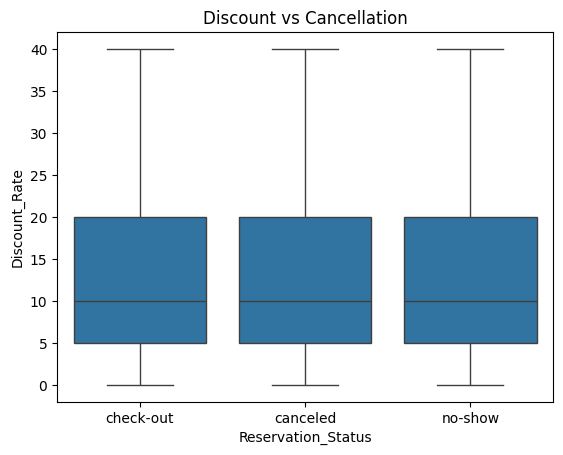

In [49]:
# discount vs cancellation
sns.boxplot(x='Reservation_Status', y='Discount_Rate', data=df)
plt.title("Discount vs Cancellation")
plt.show()

Age_Group
18-24    22.944820
25-34    23.785065
35-44    22.922304
45-54    23.028266
55-64    23.446215
65+      22.256332
nan      17.115385
Name: Is_Cancelled, dtype: float64


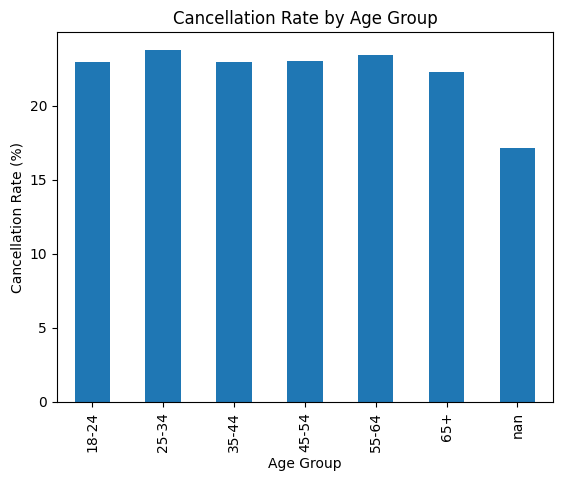

In [54]:
# create age groups
bins = [18,25,35,45,55,65,75]
labels = ['18-24','25-34','35-44','45-54','55-64','65+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels).astype(str)

# cancellation flag
df['Is_Cancelled'] = df['Reservation_Status'].isin(['canceled', 'no-show']).astype(int)

# cancel rate
cancel_rate = df.groupby('Age_Group', observed=False)['Is_Cancelled'].mean() * 100

print(cancel_rate)

# cancellation rate by age group
cancel_rate.plot(kind='bar')

plt.title("Cancellation Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Cancellation Rate (%)")

plt.show()

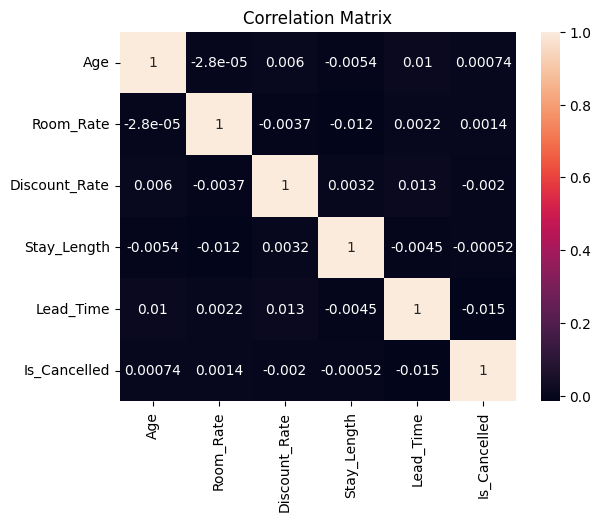

In [55]:
# correlation
corr = df[['Age','Room_Rate','Discount_Rate','Stay_Length','Lead_Time','Is_Cancelled']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

**REVENUE ANALYSIS**

In [56]:
loss_df = df[df['Is_Cancelled'] == 1]

revenue_loss = loss_df['Expected_Revenue'].sum()

print("Total Revenue Loss:", round(revenue_loss, 2))

Total Revenue Loss: 1737902.55


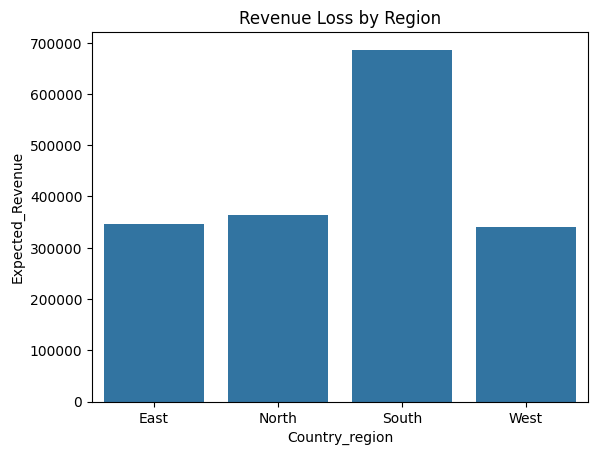

In [57]:
revenue_by_region = loss_df.groupby('Country_region')['Expected_Revenue'].sum().reset_index()

sns.barplot(x='Country_region', y='Expected_Revenue', data=revenue_by_region)
plt.title("Revenue Loss by Region")
plt.show()

**TARGET**

In [59]:
# Create Target Variable

df['Target'] = df['Reservation_Status'].map({
    'canceled': 1,
    'no-show': 1,
    'check-out': 0
})

# check
print(df['Target'].value_counts())

Target
0    20777
1     6216
Name: count, dtype: int64


**MODELLING**

Data Preparation

In [60]:
#Data Preparation

features = ['Age','Adults','Children','Babies',
            'Room_Rate','Discount_Rate','Stay_Length','Lead_Time']

X = df[features]
y = df['Target']

TRAIN TEST SPLIT

In [61]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

LOGISTIC REGRESSION

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, recall_score, confusion_matrix

# logistic model
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Accuracy: 0.47971846638266347
Recall: 0.4827018121911038
              precision    recall  f1-score   support

           0       0.76      0.48      0.59      4185
           1       0.21      0.48      0.29      1214

    accuracy                           0.48      5399
   macro avg       0.49      0.48      0.44      5399
weighted avg       0.64      0.48      0.52      5399

[[2004 2181]
 [ 628  586]]


DECISION TREE

In [63]:
from sklearn.tree import DecisionTreeClassifier

# decision tree
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.4580477866271532
Recall: 0.7380560131795717
              precision    recall  f1-score   support

           0       0.83      0.38      0.52      4185
           1       0.26      0.74      0.38      1214

    accuracy                           0.46      5399
   macro avg       0.54      0.56      0.45      5399
weighted avg       0.70      0.46      0.49      5399

[[1577 2608]
 [ 318  896]]


RANDOM FOREST

In [67]:
from sklearn.ensemble import RandomForestClassifier

# random forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.5575106501203927
Recall: 0.514003294892916
              precision    recall  f1-score   support

           0       0.80      0.57      0.67      4185
           1       0.26      0.51      0.34      1214

    accuracy                           0.56      5399
   macro avg       0.53      0.54      0.50      5399
weighted avg       0.68      0.56      0.59      5399

[[2386 1799]
 [ 590  624]]


MODEL COMPARISON

In [68]:
# compare models
import pandas as pd
from sklearn.ensemble import RandomForestClassifier # Added import for RandomForestClassifier

# Re-running Random Forest model training and prediction to define y_pred_rf
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results = pd.DataFrame({
    'Model': ['Logistic', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ]
})

print(results)

           Model  Accuracy    Recall
0       Logistic  0.479718  0.482702
1  Decision Tree  0.458048  0.738056
2  Random Forest  0.557511  0.514003


Logistic Regression Accuracy: 0.47971846638266347
Logistic Regression Recall: 0.4827018121911038
              precision    recall  f1-score   support

           0       0.76      0.48      0.59      4185
           1       0.21      0.48      0.29      1214

    accuracy                           0.48      5399
   macro avg       0.49      0.48      0.44      5399
weighted avg       0.64      0.48      0.52      5399

Decision Tree Accuracy: 0.4580477866271532
Decision Tree Recall: 0.7380560131795717
              precision    recall  f1-score   support

           0       0.83      0.38      0.52      4185
           1       0.26      0.74      0.38      1214

    accuracy                           0.46      5399
   macro avg       0.54      0.56      0.45      5399
weighted avg       0.70      0.46      0.49      5399

Random Forest Accuracy: 0.7706982774587887
Random Forest Recall: 0.0214168039538715
              precision    recall  f1-score   support

           0       0.78   

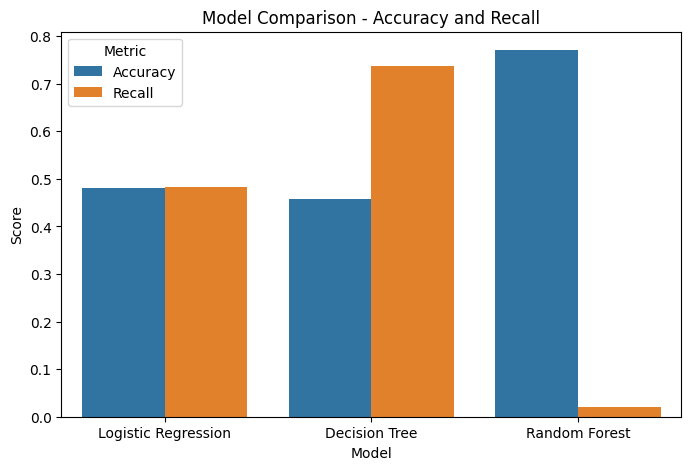

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Recall:", recall_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))


# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Recall:", recall_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, zero_division=0))


# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Recall:", recall_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))


# compare models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ]
})

print(results)


# bar chart for comparison
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8,5))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')

plt.title("Model Comparison - Accuracy and Recall")
plt.xlabel("Model")
plt.ylabel("Score")

plt.show()

In [76]:
# best model summary
best_model = results.sort_values(by='Recall', ascending=False).head(1)
best_model

f"Best model is {best_model_name} with recall = {round(best_recall, 3)}"

'Best model is Decision Tree with recall = 0.738'

Feature Importance

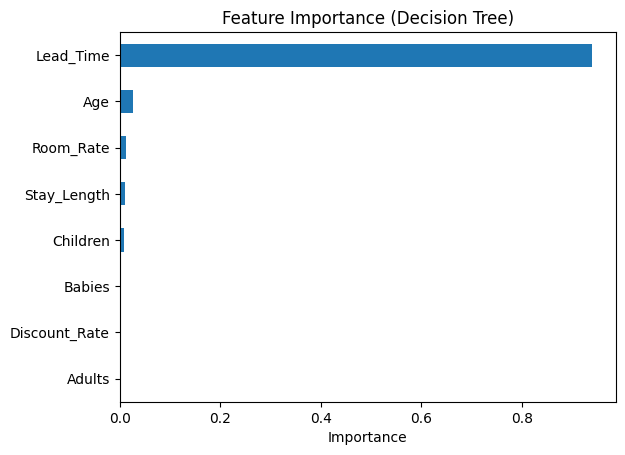

In [ ]:
# Feature Importance (Decision Tree)
importance = pd.Series(dt.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")

plt.show()

**Model Summary**

In [78]:
#The Decision Tree model was selected as the best model based on recall.33It achieved the highest ability to detect cancellations.
#Key features influencing cancellations include:
#Lead Time
#Discount Rate
#Stay Length

#This model can be used to identify high-risk bookings and reduce revenue loss.